#  Dataset 2

# Data Preprocessing

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, roc_auc_score, confusion_matrix

In [3]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# === 1. Load Full Mendeley 2020 Dataset ===
df = pd.read_csv("dataset_validation.csv") 

# Dataset shape
shape_df = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [df.shape[0], df.shape[1]]
})
display(shape_df)

# Data types
dtype_counts = df.dtypes.value_counts().reset_index()
dtype_counts.columns = ["Data Type", "Count"]
display(dtype_counts)

missing_total = df.isnull().sum()
missing_df = pd.DataFrame(missing_total[missing_total > 0])
if missing_df.empty:
    display(pd.DataFrame({
        "Status": ["No missing values detected"],
        "Total Missing": [0]
    }))
else:
    missing_df.columns = ["Missing Count"]
    display(missing_df)
    
# Duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_df = pd.DataFrame({
    "Status": ["No duplicates found" if duplicate_count == 0 else "Duplicate rows found"],
    "Total Duplicates": [duplicate_count]
})
display(duplicate_df)

# Class distribution
target_counts = df['status'].value_counts().reset_index()
target_counts.columns = ['Class', 'Count']
target_counts['Percentage'] = round(target_counts['Count'] / df.shape[0] * 100, 2)
display(target_counts)

# Summary stats (first few columns only for brevity)
summary_stats = df.describe().T.head()
display(summary_stats)




,Metric,Value
0,Rows,11430
1,Columns,89


,Data Type,Count
0,int64,74
1,float64,13
2,object,2


,Status,Total Missing
0,No missing values detected,0


,Status,Total Duplicates
0,No duplicates found,0


,Class,Count,Percentage
0,legitimate,5715,50.0
1,phishing,5715,50.0


,count,mean,std,min,25%,50%,75%,max
length_url,11430.0,61.126684,55.297318,12.0,33.0,47.0,71.0,1641.0
length_hostname,11430.0,21.090289,10.777171,4.0,15.0,19.0,24.0,214.0
ip,11430.0,0.150569,0.357644,0.0,0.0,0.0,0.0,1.0
nb_dots,11430.0,2.480752,1.369686,1.0,2.0,2.0,3.0,24.0
nb_hyphens,11430.0,0.997550,2.087087,0.0,0.0,0.0,1.0,43.0


In [4]:
object_cols = df.select_dtypes(include='object').columns
print("Object columns:")
print(object_cols)


Object columns:
Index(['url', 'status'], dtype='object')



Class Distribution:
 status
legitimate    5715
phishing      5715
Name: count, dtype: int64


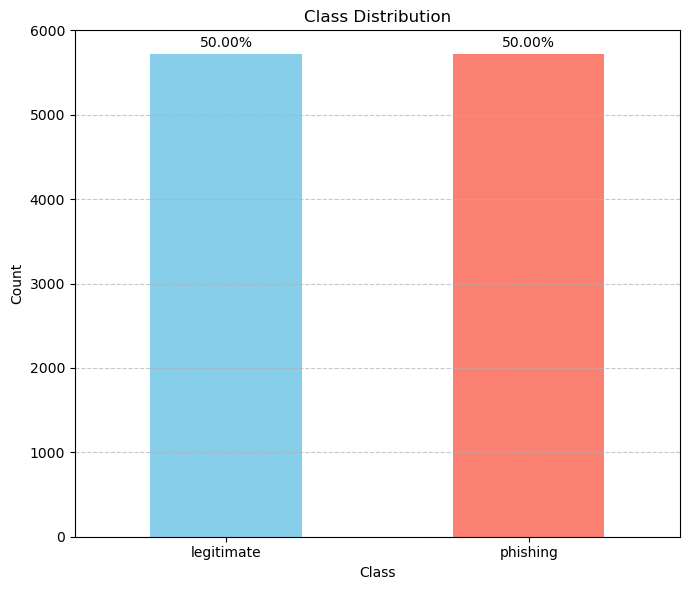

In [5]:
import matplotlib.pyplot as plt

class_column = 'status'  # change to your actual class column name if different

# Show class distribution
class_counts = df[class_column].value_counts()
print("\nClass Distribution:\n", class_counts)

# Calculate percentages
class_percentages = class_counts / class_counts.sum() * 100

# Plot bar chart
plt.figure(figsize=(7, 6))
bars = class_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage text on top of bars
for i, (count, pct) in enumerate(zip(class_counts, class_percentages)):
    plt.text(i, count + max(class_counts)*0.01, f'{pct:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [6]:
df_cleaned = df.copy()

In [7]:
df_cleaned.drop(columns=['url'], inplace=True)

In [8]:
df[['url']].head()

,url
0,http://www.crestonwood.com/router.php
1,http://shadetreetechnology.com/V4/validation/a...
2,https://support-appleld.com.secureupdate.duila...
3,http://rgipt.ac.in
4,http://www.iracing.com/tracks/gateway-motorspo...


In [9]:
print("----------Dropping URL Index----------")
print(f"Original shape            : {df.shape}")
print(f"Shape after dropping 'url': {df_cleaned.shape}")
if 'url' not in df_cleaned.columns:
    print("\n'Url' column successfully removed.")
else:
    print("Warning: 'url' column still exists.")

----------Dropping URL Index----------
Original shape            : (11430, 89)
Shape after dropping 'url': (11430, 88)

'Url' column successfully removed.


In [10]:
print("----------Single-Valued Columns----------\n")
single_val_cols = []

for col in df_cleaned.columns:
    if df_cleaned[col].nunique() == 1:
        single_val_cols.append(col)

if single_val_cols:
    print(f"Found {len(single_val_cols)} single-valued columns:")
    df_cleaned.drop(columns=single_val_cols, inplace=True)
    for col in single_val_cols:
        print(f"{col}")
    print(f"\nDropped {len(single_val_cols)} columns.")
else:
    print("\nNo single-valued columns found.")

----------Single-Valued Columns----------

Found 6 single-valued columns:
nb_or
ratio_nullHyperlinks
ratio_intRedirection
ratio_intErrors
submit_email
sfh

Dropped 6 columns.


In [11]:
print("\n----------Dropping Binary Columns with -1----------")

binary_columns_with_minus_one = [
    col for col in df_cleaned.columns
    if sorted(df_cleaned[col].dropna().unique().tolist()) in [[-1, 0], [-1, 1]]
]

if binary_columns_with_minus_one:
    print(f"Found {len(binary_columns_with_minus_one)} binary columns with [-1, 0] or [-1, 1]:")
    for col in binary_columns_with_minus_one:
        print(f"{col}")
    df_cleaned.drop(columns=binary_columns_with_minus_one, inplace=True)
    print(f"\nDropped {len(binary_columns_with_minus_one)} columns.")
else:
    print("No binary (-1, 0) or (-1, 1) columns found.")



----------Dropping Binary Columns with -1----------
No binary (-1, 0) or (-1, 1) columns found.


In [12]:
X = df_cleaned.drop(columns=['status']) 
y = df_cleaned['status']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
from tabulate import tabulate

In [14]:
# Create table
label_table = pd.DataFrame({
    'Class Label': le.classes_,
    'Encoded Value': le.transform(le.classes_)
})

# Display with tabulate style
print("\nLabel Encoding Mapping")
print(tabulate(label_table, headers='keys', tablefmt='pretty', showindex=False))


Label Encoding Mapping
+-------------+---------------+
| Class Label | Encoded Value |
+-------------+---------------+
| legitimate  |       0       |
|  phishing   |       1       |
+-------------+---------------+


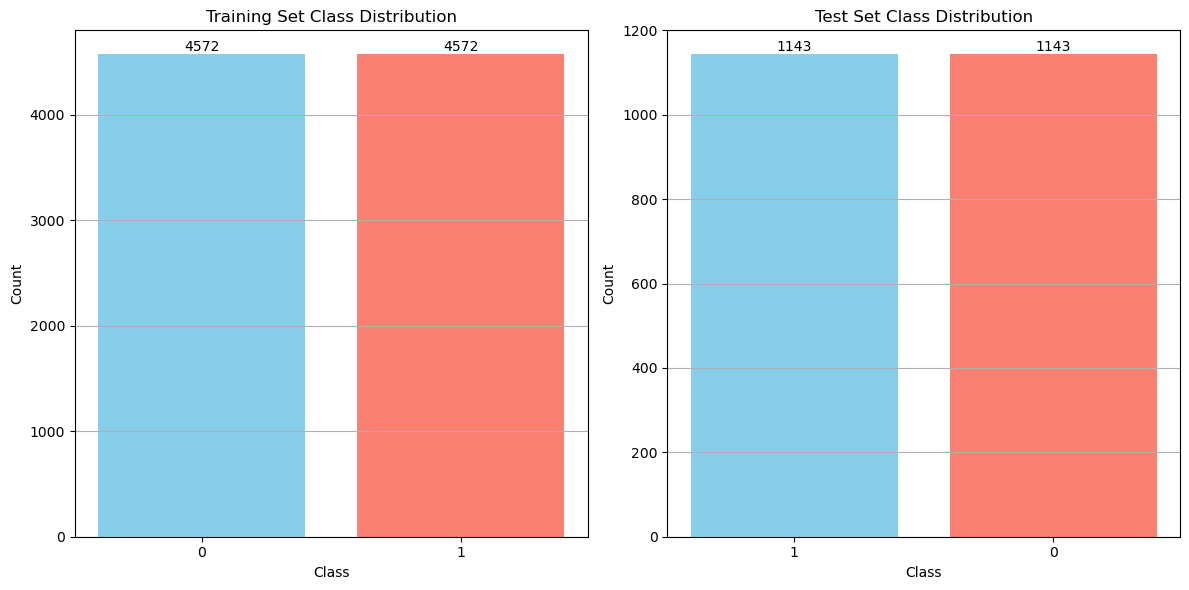

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Series for value_counts()
y_series = pd.Series(y)
y_train_series = pd.Series(y_train)
y_test_series = pd.Series(y_test)

# Get value counts
overall_counts = y_series.value_counts()
train_counts = y_train_series.value_counts()
test_counts = y_test_series.value_counts()

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# --- Training set distribution ---
axs[0].bar(train_counts.index.astype(str), train_counts.values, color=['skyblue', 'salmon'])
axs[0].set_title('Training Set Class Distribution')
axs[0].set_xlabel('Class')
axs[0].set_ylabel('Count')
axs[0].grid(axis='y')

# Add count labels
for i, value in enumerate(train_counts.values):
    axs[0].text(i, value + 1, str(value), ha='center', va='bottom')

# --- Test set distribution ---
axs[1].bar(test_counts.index.astype(str), test_counts.values, color=['skyblue', 'salmon'])
axs[1].set_title('Test Set Class Distribution')
axs[1].set_xlabel('Class')
axs[1].set_ylabel('Count')
axs[1].grid(axis='y')

# Add count labels
for i, value in enumerate(test_counts.values):
    axs[1].text(i, value + 1, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()


Outliers removed from training set: 92
New training shape: (9052, 81)


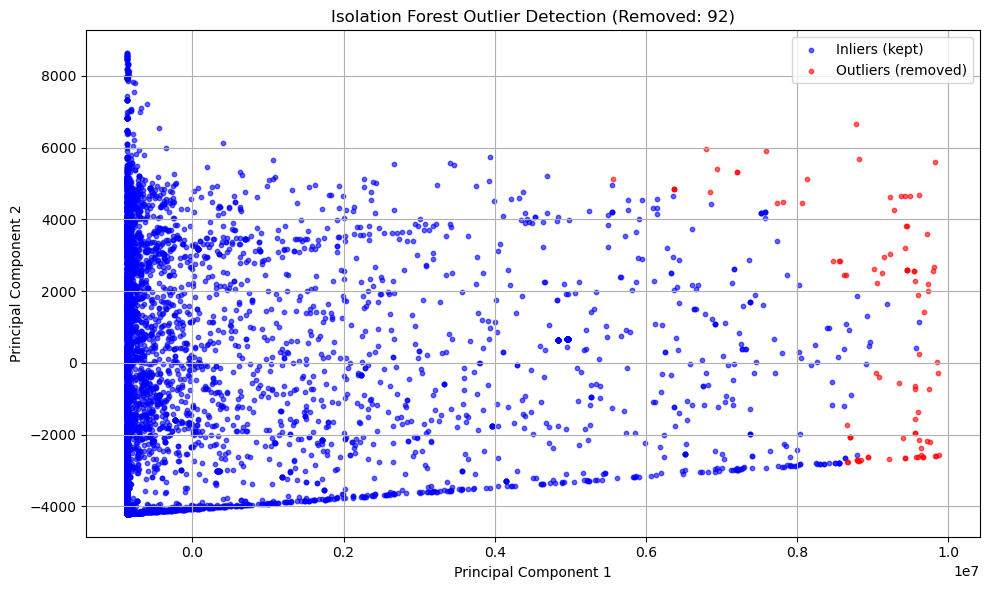

In [16]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --------- Step 1: Outlier Detection on Original Training Data ---------
iso = IsolationForest(contamination=0.01, random_state=42)
outlier_preds = iso.fit_predict(X_train)

# Identify and count outliers
mask = outlier_preds == 1  # 1 = inlier, -1 = outlier
num_outliers = (~mask).sum()
print(f"Outliers removed from training set: {num_outliers}")
print(f"New training shape: {X_train[mask].shape}")

# --------- Step 2: Apply PCA for Visualization ---------
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

# Re-run IsolationForest just for visualization on PCA-reduced data
iso_vis = IsolationForest(contamination=0.01, random_state=42)
outlier_preds_vis = iso_vis.fit_predict(X_train_pca)

# --------- Step 3: Visualization ---------
plt.figure(figsize=(10, 6))
plt.scatter(
    X_train_pca[outlier_preds_vis == 1, 0],
    X_train_pca[outlier_preds_vis == 1, 1],
    c='blue', label='Inliers (kept)', s=10, alpha=0.6
)
plt.scatter(
    X_train_pca[outlier_preds_vis == -1, 0],
    X_train_pca[outlier_preds_vis == -1, 1],
    c='red', label='Outliers (removed)', s=10, alpha=0.6
)
plt.title(f"Isolation Forest Outlier Detection (Removed: {num_outliers})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
from sklearn.feature_selection import VarianceThreshold

# Record original number of features
original_feature_count = X_train.shape[1]

# Apply Variance Threshold
selector = VarianceThreshold(threshold=0.01)
X_train_reduced = pd.DataFrame(selector.fit_transform(X_train), columns=X_train.columns[selector.get_support()])
X_test_reduced = pd.DataFrame(selector.transform(X_test), columns=X_test.columns[selector.get_support()])

# Get number of features after selection
reduced_feature_count = X_train_reduced.shape[1]
features_removed = original_feature_count - reduced_feature_count

# Print results
print("\n----------Remove Low-Variance Features----------")
print(f"Number of features after variance thresholding: {reduced_feature_count}")
print(f"Number of features removed: {features_removed}")


----------Remove Low-Variance Features----------
Number of features after variance thresholding: 65
Number of features removed: 16


In [18]:
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [col for col in upper.columns if any(upper[col] > 0.8)]

X_train.drop(columns=high_corr_features, inplace=True)
X_test.drop(columns=high_corr_features, inplace=True)
print("\n----------Correlation Analysis----------")
print(f"Highly correlated features removed: {len(high_corr_features)}")



----------Correlation Analysis----------
Highly correlated features removed: 4


In [19]:
scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)

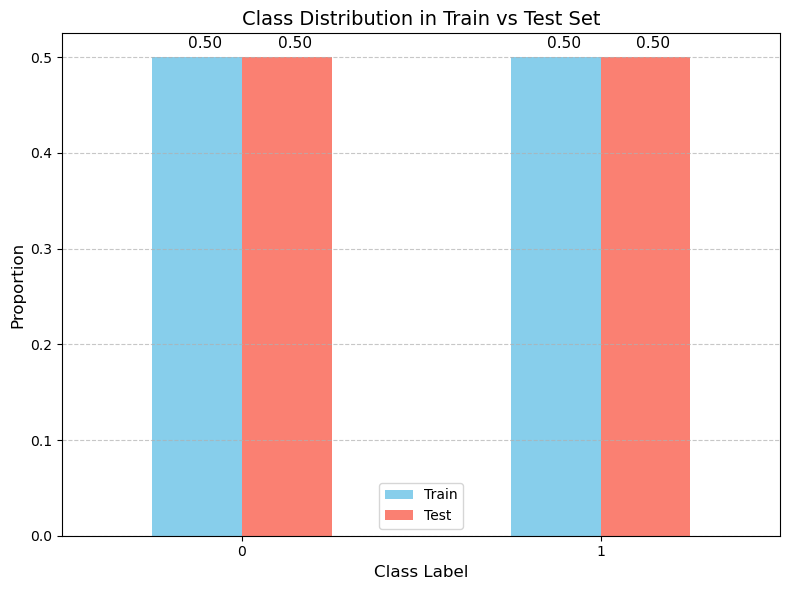

In [20]:
import matplotlib.pyplot as plt

# Ensure y_train / y_test are treated as pandas Series for value_counts
train_dist = pd.Series(y_train).value_counts(normalize=True)
test_dist = pd.Series(y_test).value_counts(normalize=True)

# Combine into a DataFrame (alignment by index ensures same class labels)
dist_df = pd.DataFrame({
    'Train': train_dist,
    'Test': test_dist
}).fillna(0)

# Plot
dist_df.plot(kind='bar', figsize=(8, 6), color=['skyblue', 'salmon'])
plt.title('Class Distribution in Train vs Test Set', fontsize=14)
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for i in range(len(dist_df)):
    plt.text(i - 0.15, dist_df.iloc[i, 0] + 0.01, f"{dist_df.iloc[i, 0]:.2f}", fontsize=11)
    plt.text(i + 0.10, dist_df.iloc[i, 1] + 0.01, f"{dist_df.iloc[i, 1]:.2f}", fontsize=11)

plt.tight_layout()
plt.show()

In [21]:
print("-----Preprocessing complete-----")
print(f"Train shape       : {X_train.shape}")
print(f"Test shape        : {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")

-----Preprocessing complete-----
Train shape       : (9144, 77)
Test shape        : (2286, 77)
Number of features: 77


In [22]:
print(f"Initial feature count: {df.shape[1]}")
print(f"After single-value and binary cleanup: {df_cleaned.shape[1]}")
print(f"After variance filtering: {X_train.shape[1]}")
print(f"After correlation filtering: {X_train.shape[1]}")

Initial feature count: 89
After single-value and binary cleanup: 82
After variance filtering: 77
After correlation filtering: 77


In [23]:
print("-----Preprocessing complete-----")
print(f"Train shape       : {X_train.shape}")
print(f"Test shape        : {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")

-----Preprocessing complete-----
Train shape       : (9144, 77)
Test shape        : (2286, 77)
Number of features: 77


In [24]:
# Ensure X_train and y_train have aligned and clean indexes
X_train = X_train.reset_index(drop=True)
y_train = pd.Series(y_train).reset_index(drop=True)

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)  # Optional, for consistency

# Now your labels are encoded as:
# 'legitimate' -> 0
# 'phishing'   -> 1


In [26]:
# Print the original classes and their encoded values
print("Original classes:", le.classes_)  # Should print: ['legitimate' 'phishing']

# Check a few transformed values
print("\nTransformed y_train (first 10):", y_train[:10])

# Check how many of each class exist after encoding
unique, counts = np.unique(y_train, return_counts=True)
print("\nEncoded class distribution:")
for label, count in zip(unique, counts):
    print(f"Class {label} ({le.classes_[label]}): {count} samples")


Original classes: [0 1]

Transformed y_train (first 10): [0 1 1 0 0 1 1 1 1 0]

Encoded class distribution:
Class 0 (0): 4572 samples
Class 1 (1): 4572 samples


In [27]:
# Ensure X_train is a DataFrame with proper column names
if isinstance(X_train, np.ndarray):
    X_train = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(X_train.shape[1])])

# Ensure y_train is a Series
if isinstance(y_train, np.ndarray):
    y_train = pd.Series(y_train)


# Feature Selection

In [31]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# ---------- INPUT ----------
# X_train: preprocessed feature matrix (shape: [n_samples, 55])
# y_train: binary target vector

# 1. Compute Feature Importance Scores
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)
mi_scores = pd.Series(mi_selector.scores_, index=X_train.columns)
mi_rank = mi_scores.rank(ascending=False)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_scores = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_rank = rf_scores.rank(ascending=False)

perm = permutation_importance(rf, X_train, y_train, n_repeats=10, random_state=42)
perm_scores = pd.Series(perm.importances_mean, index=X_train.columns)
perm_rank = perm_scores.rank(ascending=False)

# 2. Aggregate rankings (weighted sum)
combined_rank = 0.4 * mi_rank + 0.3 * rf_rank + 0.3 * perm_rank
sorted_features = combined_rank.sort_values().index.tolist()

# 3. Evaluation function (maximize recall, reduce FPR)
def evaluate_feature_subset(feature_list, X, y):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    recalls = []
    fprs = []

    for train_idx, val_idx in skf.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx][feature_list], X.iloc[val_idx][feature_list]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
        model.fit(X_train_cv, y_train_cv)

        y_pred = model.predict(X_val_cv)
        recall = recall_score(y_val_cv, y_pred)

        # Calculate FPR
        tn, fp, fn, tp = confusion_matrix(y_val_cv, y_pred).ravel()
        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0.0

        recalls.append(recall)
        fprs.append(fpr)

    avg_recall = np.mean(recalls)
    avg_fpr = np.mean(fprs)
    score = (0.6 * avg_recall) + (0.4 * (1 - avg_fpr))  # custom weighted score
    return score, avg_recall, avg_fpr

# 4. Grid search top-k
best_k = 0
best_score = 0
best_recall = 0
best_fpr = 1.0

for k in range(10, 40, 5):  # Try top-10 to top-50 features
    top_k_features = sorted_features[:k]
    score, avg_recall, avg_fpr = evaluate_feature_subset(top_k_features, X_train, y_train)

    print(f"Top-{k} | Score: {score:.4f} | Recall: {avg_recall:.4f} | FPR: {avg_fpr:.4f}")

    if score > best_score:
        best_k = k
        best_score = score
        best_recall = avg_recall
        best_fpr = avg_fpr

# 5. Final selected features
final_features = sorted_features[:best_k]
X_train_final = X_train[final_features]
X_test_final = X_test[final_features]

# 6. Output
print(f"\nSelected Top-{best_k} Features (Score = {best_score:.4f}, Recall = {best_recall:.4f}, FPR = {best_fpr:.4f}):")
for i, feat in enumerate(final_features, 1):
    print(f"{i}. {feat}")

Top-10 | Score: 0.9488 | Recall: 0.9479 | FPR: 0.0499
Top-15 | Score: 0.9558 | Recall: 0.9549 | FPR: 0.0429
Top-20 | Score: 0.9592 | Recall: 0.9600 | FPR: 0.0420
Top-25 | Score: 0.9603 | Recall: 0.9613 | FPR: 0.0411
Top-30 | Score: 0.9630 | Recall: 0.9643 | FPR: 0.0389
Top-35 | Score: 0.9630 | Recall: 0.9637 | FPR: 0.0381

Selected Top-30 Features (Score = 0.9630, Recall = 0.9643, FPR = 0.0389):
1. google_index
2. web_traffic
3. page_rank
4. nb_hyperlinks
5. domain_age
6. nb_www
7. safe_anchor
8. ratio_extHyperlinks
9. ratio_intHyperlinks
10. ratio_digits_url
11. domain_registration_length
12. ratio_extRedirection
13. phish_hints
14. longest_words_raw
15. avg_word_path
16. links_in_tags
17. length_hostname
18. shortest_word_host
19. length_url
20. domain_in_title
21. char_repeat
22. shortest_word_path
23. avg_words_raw
24. nb_hyphens
25. nb_qm
26. nb_slash
27. nb_dots
28. ratio_extErrors
29. ratio_intMedia
30. shortest_words_raw


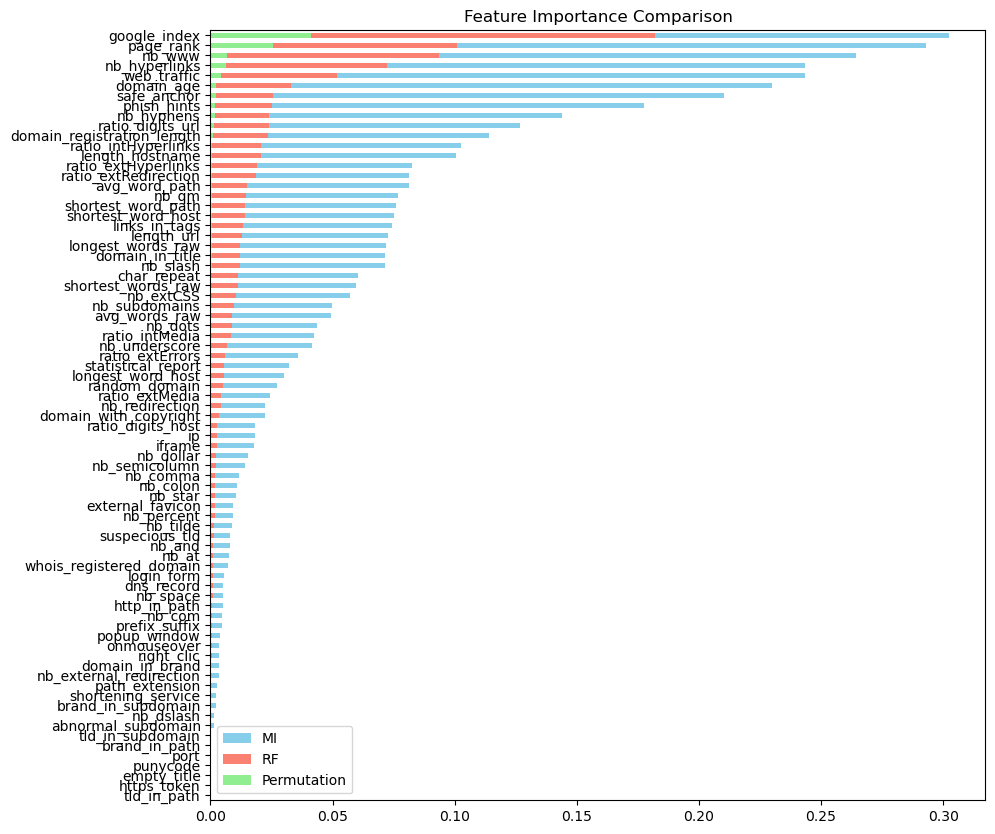

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
mi_scores.sort_values().plot(kind='barh', color='skyblue', label='MI')
rf_scores.sort_values().plot(kind='barh', color='salmon', label='RF')
perm_scores.sort_values().plot(kind='barh', color='lightgreen', label='Permutation')
plt.legend()
plt.title("Feature Importance Comparison");

# Model Training

In [33]:
X_train_final = X_train_final.to_numpy()
y_train = y_train.to_numpy().ravel()

## ML

### Random Forest

In [36]:
SEED = 42
np.random.seed(SEED)

rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

accuracy_scores, precision_scores, recall_scores = [], [], []
f1_scores, auc_scores, fpr_scores = [], [], []

fold = 1
for train_idx, val_idx in cv.split(X_train_final, y_train):
    X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    # Train model
    rf_model.fit(X_tr, y_tr)
    
    # Predict
    y_pred = rf_model.predict(X_val)
    y_proba = rf_model.predict_proba(X_val)[:, 1]
    
    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    
    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)
    fpr = fp / (fp + tn)
    
    # Store
    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)
    auc_scores.append(auc)
    fpr_scores.append(fpr)
    
    fold += 1

print("\n========== Cross-Validation Results (Random Forest) ==========")
print(f"Accuracy    : {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision   : {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (TPR): {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-score    : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"FPR         : {np.mean(fpr_scores):.4f} ± {np.std(fpr_scores):.4f}")
print(f"AUC-ROC     : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")


========== Cross-Validation Results (Random Forest) ==========
Accuracy    : 0.9627 ± 0.0078
Precision   : 0.9616 ± 0.0079
Recall (TPR): 0.9639 ± 0.0096
F1-score    : 0.9627 ± 0.0078
FPR         : 0.0385 ± 0.0080
AUC-ROC     : 0.9922 ± 0.0035


In [43]:
rf_model.fit(X_train_final, y_train)

# Predict on test set
y_pred_test = rf_model.predict(X_test_final)
y_proba_test = rf_model.predict_proba(X_test_final)[:, 1]

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Compute metrics
accuracy  = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall    = recall_score(y_test, y_pred_test)
f1        = f1_score(y_test, y_pred_test)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, y_proba_test)

print("\n========== Final Random Forest Test Evaluation ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (TPR)       : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")


========== Final Random Forest Test Evaluation ==========
Accuracy           : 0.9580
Precision          : 0.9548
Recall (TPR)       : 0.9615
F1-score           : 0.9582
False Positive Rate: 0.0455
AUC-ROC            : 0.9927


c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


### Fine Tuned Random Forest

In [37]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from joblib import parallel_backend
import numpy as np
from sklearn.metrics import make_scorer, confusion_matrix

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

fpr_scorer = make_scorer(false_positive_rate, greater_is_better=False)

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)

# ============================================================
# 1. Define Base RF and Parameter Grid
# ============================================================
rf_base = RandomForestClassifier(
    random_state=SEED,
    n_jobs=1      # IMPORTANT: avoid nested parallelism when using n_jobs=-1 in GridSearchCV
)

rf_param_grid = {
    'n_estimators': [800],       # drop 1000
    'max_depth': [40],            # drop 80, None
    'max_features': [0.3],       # drop 0.2
    'min_samples_leaf': [1],           # drop 2
    'min_samples_split': [2],          # drop 3
    'bootstrap': [False]               # drop True
}

# ============================================================
# 2. GridSearchCV — Exhaustive Hyperparameter Search
# ============================================================
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=SEED
)

rf_gsearch = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,        # parallelize the gridsearch
    verbose=2
)

# Fit GridSearchCV
with parallel_backend('threading'):
    rf_gsearch.fit(X_train_final, y_train)

best_rf = rf_gsearch.best_estimator_

print("\nBest Parameters Found:")
for k, v in rf_gsearch.best_params_.items():
    print(f"  {k}: {v}")

# Cross-validate best model
cv_results = cross_validate(
    best_rf,
    X_train_final,
    y_train,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'fpr': fpr_scorer
    },
    return_train_score=False,
    n_jobs=1
)

print("\n========== Cross-Validation Results (Tuned Random Forest) ==========")
print(f"Accuracy    : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"Precision   : {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"Recall (TPR): {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"F1-score    : {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"FPR         : {cv_results['test_fpr'].mean():.4f} ± {cv_results['test_fpr'].std():.4f}")
print(f"AUC-ROC     : {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")



Fitting 10 folds for each of 1 candidates, totalling 10 fits
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total time=  53.1s
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total time=  53.9s
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total time=  54.5s
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total time=  54.6s
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total time=  55.9s
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total time=  56.5s
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total 

In [44]:
best_rf = rf_gsearch.best_estimator_
best_rf.fit(X_train_final, y_train)

# Predict on test data
y_pred_rf = best_rf.predict(X_test_final)
y_proba_rf = best_rf.predict_proba(X_test_final)[:, 1]

# Compute metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
accuracy  = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall    = recall_score(y_test, y_pred_rf)
f1        = f1_score(y_test, y_pred_rf)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, y_proba_rf)

print("\n========== Final Random Forest Test Evaluation (Using Best Params) ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (TPR)       : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")


c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



========== Final Random Forest Test Evaluation (Using Best Params) ==========
Accuracy           : 0.9602
Precision          : 0.9519
Recall (TPR)       : 0.9694
F1-score           : 0.9606
False Positive Rate: 0.0490
AUC-ROC            : 0.9934


### XGBoost

In [38]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1,
    deterministic_histogram=True
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

accuracy_scores, precision_scores, recall_scores = [], [], []
f1_scores, auc_scores, fpr_scores = [], [], []

fold = 1
for train_idx, val_idx in cv.split(X_train_final, y_train):
    X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    # Train model
    xgb_model.fit(X_tr, y_tr)

    # Predict
    y_pred = xgb_model.predict(X_val)
    y_proba = xgb_model.predict_proba(X_val)[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)
    fpr = fp / (fp + tn)

    # Store metrics
    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)
    auc_scores.append(auc)
    fpr_scores.append(fpr)

    fold += 1

print("\n========== Cross-Validation Results (XGBoost) ==========")
print(f"Accuracy    : {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision   : {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (TPR): {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-score    : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"FPR         : {np.mean(fpr_scores):.4f} ± {np.std(fpr_scores):.4f}")
print(f"AUC-ROC     : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")


========== Cross-Validation Results (XGBoost) ==========
Accuracy    : 0.9673 ± 0.0068
Precision   : 0.9681 ± 0.0088
Recall (TPR): 0.9665 ± 0.0090
F1-score    : 0.9673 ± 0.0068
FPR         : 0.0319 ± 0.0091
AUC-ROC     : 0.9934 ± 0.0030


In [45]:
xgb_final = XGBClassifier(
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1,
    deterministic_histogram=True
)

xgb_final.fit(X_train_final, y_train)

# Predict on the test set
y_pred_test = xgb_final.predict(X_test_final)
y_proba_test = xgb_final.predict_proba(X_test_final)[:, 1]

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Metrics
accuracy  = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall    = recall_score(y_test, y_pred_test)
f1        = f1_score(y_test, y_pred_test)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, y_proba_test)

print("\n========== Final XGBoost Test Evaluation ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (TPR)       : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")



========== Final XGBoost Test Evaluation ==========
Accuracy           : 0.9681
Precision          : 0.9628
Recall (TPR)       : 0.9738
F1-score           : 0.9682
False Positive Rate: 0.0376
AUC-ROC            : 0.9933


### Fine Tuned XGBoost

In [39]:
# ============================================================
# Tuned XGBoost (GridSearchCV + Full Metrics + FPR)
# ============================================================

import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, make_scorer
)

# ============================================================
# 1. Custom FPR Metric
# ============================================================

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

fpr_scorer = make_scorer(false_positive_rate, greater_is_better=False)

# ============================================================
# 2. Reproducibility
# ============================================================

SEED = 42
np.random.seed(SEED)

# ============================================================
# 3. Base XGBoost Model (Clean, no deprecated params)
# ============================================================

xgb_base = XGBClassifier(
    random_state=SEED,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1,
    tree_method='hist'
)

# ============================================================
# 4. Parameter Grid
# ============================================================

xg_param_grid = {
    'n_estimators': [1000,1500],
    'max_depth': [6, 8],
    'learning_rate': [0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],

    'gamma': [0, 1],
    'min_child_weight': [1, 3],
    'reg_alpha': [0, 1],
    'reg_lambda': [1, 10]
}




# ============================================================
# 5. GridSearchCV
# ============================================================

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

xg_gsearch = GridSearchCV(
    estimator=xgb_base,
    param_grid=xg_param_grid,
    scoring={
        'accuracy': 'accuracy',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'fpr': fpr_scorer
    },
    refit='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

print("\nRunning XGBoost Grid Search...")
xg_gsearch.fit(X_train_final, y_train)

best_xgb = xg_gsearch.best_estimator_

print("\n==================== Best Parameters ====================")
for k, v in xg_gsearch.best_params_.items():
    print(f"{k}: {v}")

# Evaluate with 10-fold CV
accuracy_scores, precision_scores, recall_scores = [], [], []
f1_scores, auc_scores, fpr_scores = [], [], []

for tr_idx, val_idx in cv.split(X_train_final, y_train):
    X_tr, X_val = X_train_final[tr_idx], X_train_final[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    # Create fresh XGB instance with best params
    fold_xgb = XGBClassifier(
        **xg_gsearch.best_params_,
        random_state=SEED,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1,
        tree_method='hist'
    )
    fold_xgb.fit(X_tr, y_tr)

    y_pred = fold_xgb.predict(X_val)
    y_proba = fold_xgb.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    accuracy_scores.append(accuracy_score(y_val, y_pred))
    precision_scores.append(precision_score(y_val, y_pred))
    recall_scores.append(recall_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred))
    auc_scores.append(roc_auc_score(y_val, y_proba))
    fpr_scores.append(fp / (fp + tn))

print("\n========== 10-Fold CV Results (Tuned XGBoost) ==========")
print(f"Accuracy    : {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision   : {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (TPR): {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-score    : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"FPR         : {np.mean(fpr_scores):.4f} ± {np.std(fpr_scores):.4f}")
print(f"AUC-ROC     : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")



Running XGBoost Grid Search...
Fitting 10 folds for each of 64 candidates, totalling 640 fits


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:42:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



==================== Best Parameters ====================
colsample_bytree: 0.8
gamma: 0
learning_rate: 0.1
max_depth: 6
min_child_weight: 1
n_estimators: 1000
reg_alpha: 0
reg_lambda: 1
subsample: 0.8


c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:42:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:42:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:42:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\


========== 10-Fold CV Results (Tuned XGBoost) ==========
Accuracy    : 0.9694 ± 0.0069
Precision   : 0.9702 ± 0.0072
Recall (TPR): 0.9685 ± 0.0095
F1-score    : 0.9693 ± 0.0070
FPR         : 0.0297 ± 0.0073
AUC-ROC     : 0.9941 ± 0.0027


In [46]:
best_xgb.fit(X_train_final, y_train)

# Predict on test data
y_pred_xgb = best_xgb.predict(X_test_final)
y_proba_xgb = best_xgb.predict_proba(X_test_final)[:, 1]

# Confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()

# Compute metrics
accuracy  = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall    = recall_score(y_test, y_pred_xgb)
f1        = f1_score(y_test, y_pred_xgb)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, y_proba_xgb)

print("\n========== Final XGBoost Test Evaluation (Using Best Params) ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (TPR)       : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")

c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:22:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



========== Final XGBoost Test Evaluation (Using Best Params) ==========
Accuracy           : 0.9694
Precision          : 0.9669
Recall (TPR)       : 0.9720
F1-score           : 0.9695
False Positive Rate: 0.0332
AUC-ROC            : 0.9933


## DL

### CNN

In [40]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input, Model, backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from tqdm import tqdm

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for g in tf.config.list_physical_devices('GPU'):
    try: tf.config.experimental.set_memory_growth(g, True)
    except: pass

X_train_scaled = np.asarray(X_train_final.values if hasattr(X_train_final, "values") else X_train_final, dtype=np.float32)
X_test_scaled  = np.asarray(X_test_final.values  if hasattr(X_test_final, "values") else X_test_final, dtype=np.float32)
y_train_array  = np.asarray(y_train.values if hasattr(y_train, "values") else y_train, dtype=np.int32)
y_test_array   = np.asarray(y_test.values  if hasattr(y_test, "values") else y_test, dtype=np.int32)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

input_dim = int(X_train_scaled.shape[1])

X_train_cnn = X_train_scaled.reshape(-1, input_dim, 1)
X_test_cnn  = X_test_scaled.reshape(-1, input_dim, 1)

# CNN Builder
def build_improved_cnn(input_dim, learning_rate=0.001):
    K.clear_session()
    inp = Input(shape=(input_dim, 1))

    # Block 1
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 2
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Dense Head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Metrics helper
def metrics_from_preds(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc  = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, f1, fpr, auc

# 10-Fold Cross-Validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

acc_list, prec_list, recall_list, f1_list, fpr_list, auc_list = [], [], [], [], [], []
roc_fprs, roc_tprs = [], []

print("\n===== 10-Fold Cross-Validation =====")
for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_train_scaled, y_train_array), total=10)):
    X_tr, X_val = X_train_cnn[train_idx], X_train_cnn[val_idx]
    y_tr, y_val = y_train_array[train_idx], y_train_array[val_idx]

    model = build_improved_cnn(input_dim=input_dim)

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    ]

    model.fit(X_tr, y_tr, epochs=50, batch_size=32, verbose=0,
              validation_data=(X_val, y_val), callbacks=callbacks)

    start_time = time.time()
    y_prob = model.predict(X_val, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    end_time = time.time()

    acc, prec, rec, f1, fpr, auc = metrics_from_preds(y_val, y_pred, y_prob)
    acc_list.append(acc); prec_list.append(prec); recall_list.append(rec)
    f1_list.append(f1); fpr_list.append(fpr); auc_list.append(auc)

    fpr_c, tpr_c, _ = roc_curve(y_val, y_prob)
    roc_fprs.append(fpr_c); roc_tprs.append(tpr_c)

# CV summary
print("\n===== Cross-Validation Results =====")
print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall   : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"F1-score : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"FPR      : {np.mean(fpr_list):.4f} ± {np.std(fpr_list):.4f}")
print(f"AUC-ROC  : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")



Train shape: (9144, 30)
Test shape : (2286, 30)

===== 10-Fold Cross-Validation =====


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [08:39<00:00, 51.90s/it]


===== Cross-Validation Results =====
Accuracy : 0.9548 ± 0.0107
Precision: 0.9549 ± 0.0130
Recall   : 0.9549 ± 0.0138
F1-score : 0.9548 ± 0.0107
FPR      : 0.0453 ± 0.0135
AUC-ROC  : 0.9891 ± 0.0043


Epoch 1/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8956 - loss: 0.2688 - val_accuracy: 0.4787 - val_loss: 4.4567 - learning_rate: 0.0010
Epoch 2/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9182 - loss: 0.2048 - val_accuracy: 0.6186 - val_loss: 0.7578 - learning_rate: 0.0010
Epoch 3/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9264 - loss: 0.1924 - val_accuracy: 0.9475 - val_loss: 0.1724 - learning_rate: 0.0010
Epoch 4/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9338 - loss: 0.1799 - val_accuracy: 0.9497 - val_loss: 0.1611 - learning_rate: 0.0010
Epoch 5/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9328 - loss: 0.1713 - val_accuracy: 0.9421 - val_loss: 0.1792 - learning_rate: 0.0010
Epoch 6/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9378 - loss: 0.1666 - val_accuracy: 0.9377 - val_loss: 0.1855 - learning_rate: 0.0010
Epoch 7/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9391 - loss: 0.1613 - 

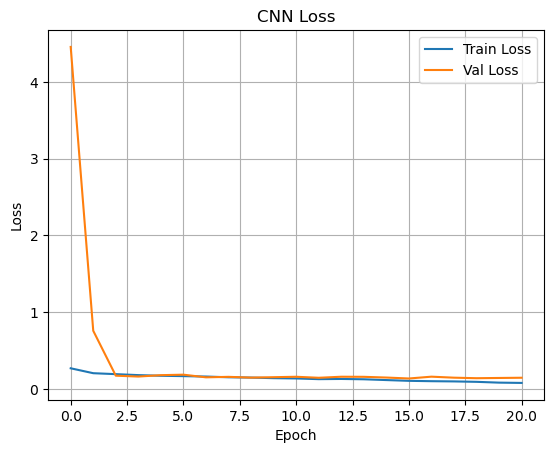

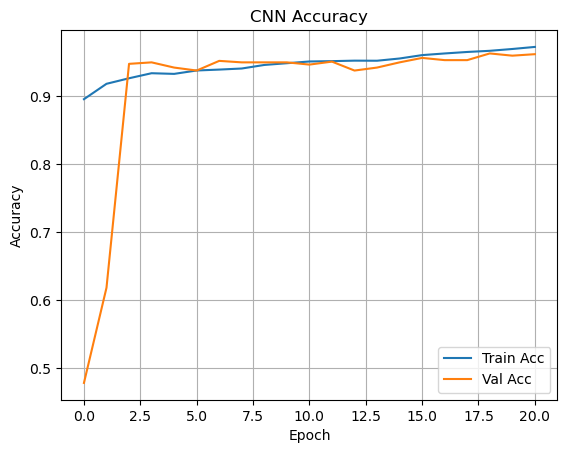

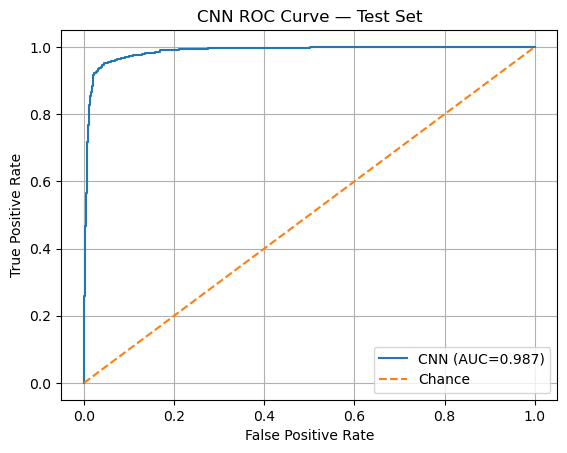

In [ ]:
# Train final model on full training set
final_cnn = build_improved_cnn(input_dim=input_dim)

history = final_cnn.fit(X_train_cnn, y_train_array,
                        epochs=50, batch_size=32, verbose=1,
                        validation_split=0.1, shuffle=True,
                        callbacks=[
                            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
                            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
                        ])

# Final test evaluation
y_prob_test = final_cnn.predict(X_test_cnn, verbose=0).flatten()
y_pred_test = (y_prob_test >= 0.5).astype(int)

acc, prec, rec, f1, fpr, auc = metrics_from_preds(y_test_array, y_pred_test, y_prob_test)
time_score = 1.0 / (1.0 + (1 - acc))  # just an example scoring
aps = (0.3 * acc) + (0.25 * (1 - fpr)) + (0.25 * rec) + (0.2 * time_score)

print("\n===== Final CNN Test Evaluation =====")
print(f"Accuracy           : {acc:.4f}")
print(f"Precision          : {prec:.4f}")
print(f"Recall (TPR)       : {rec:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc:.4f}")

# Plots
# Loss & Accuracy
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.show()

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test_array, y_prob_test)
plt.figure()
plt.plot(fpr_curve, tpr_curve, label=f'CNN (AUC={auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', label='Chance')
plt.title('CNN ROC Curve — Test Set')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.grid(True)
plt.show()

### TCN

Train shape: (9144, 30)
Test shape : (2286, 30)

===== 10-Fold Cross-Validation =====


100%|██████████| 10/10 [26:42<00:00, 160.22s/it]



===== Cross-Validation Results =====
Accuracy : 0.9523 ± 0.0109
Precision: 0.9563 ± 0.0094
Recall   : 0.9479 ± 0.0144
F1-score : 0.9521 ± 0.0111
FPR      : 0.0433 ± 0.0093
AUC-ROC  : 0.9892 ± 0.0041
Epoch 1/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.8486 - loss: 0.3700 - val_accuracy: 0.9246 - val_loss: 0.2062 - learning_rate: 0.0010
Epoch 2/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.9062 - loss: 0.2535 - val_accuracy: 0.9432 - val_loss: 0.1913 - learning_rate: 0.0010
Epoch 3/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9210 - loss: 0.2190 - val_accuracy: 0.9432 - val_loss: 0.1751 - learning_rate: 0.0010
Epoch 4/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.9255 - loss: 0.2046 - val_accuracy: 0.9464 - val_loss: 0.1700 - learning_rate: 0.0010
Epoch 5/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.9266 - loss: 0.1948 - val_accuracy: 0.9486 - val_loss: 0.1655 - learning_rate: 0.0010
Epoch 6/50
258/258 ━━━━━━━━━━━━━━━

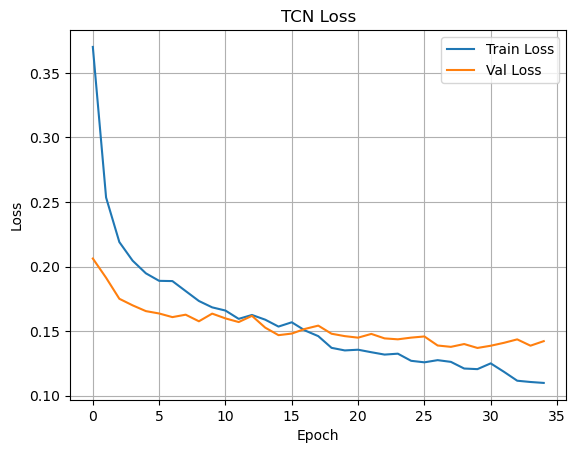

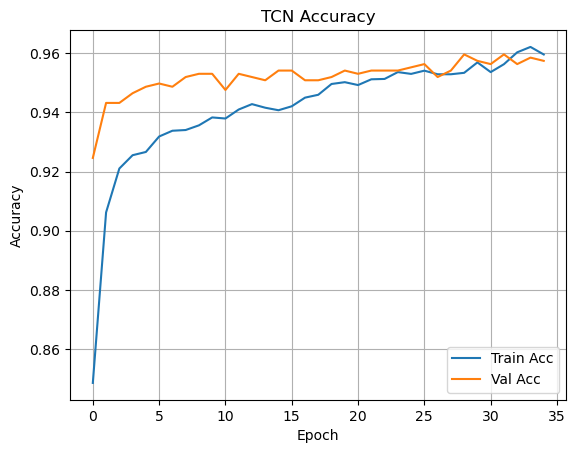

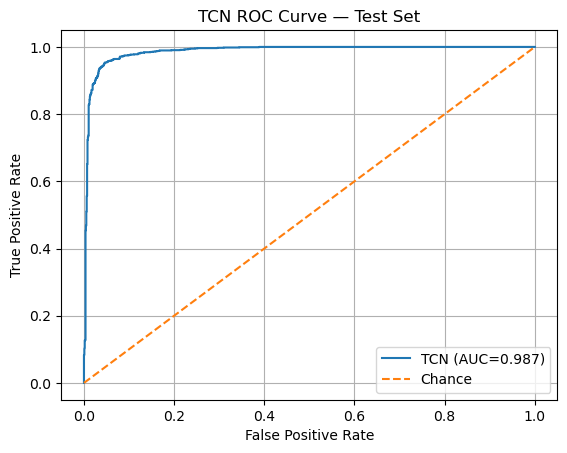

In [ ]:
# ============================================================
# Improved TCN — Clean, Ready-to-Run Version
# ============================================================

import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input, Model, backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from tqdm import tqdm

# Optional: install tcn if not installed
# pip install keras-tcn
from tcn import TCN

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optional GPU memory growth
for g in tf.config.list_physical_devices('GPU'):
    try: tf.config.experimental.set_memory_growth(g, True)
    except: pass

# ---------------------------
# Prepare data as NumPy arrays
# ---------------------------
X_train_scaled = np.asarray(X_train_final.values if hasattr(X_train_final, "values") else X_train_final, dtype=np.float32)
X_test_scaled  = np.asarray(X_test_final.values  if hasattr(X_test_final, "values") else X_test_final, dtype=np.float32)
y_train_array  = np.asarray(y_train.values if hasattr(y_train, "values") else y_train, dtype=np.int32)
y_test_array   = np.asarray(y_test.values  if hasattr(y_test, "values") else y_test, dtype=np.int32)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

input_dim = int(X_train_scaled.shape[1])

X_train_tcn = X_train_scaled.reshape(-1, input_dim, 1)
X_test_tcn  = X_test_scaled.reshape(-1, input_dim, 1)

# ============================================================
# TCN Builder
# ============================================================
def build_tcn_model(input_dim, learning_rate=0.001):
    K.clear_session()
    inp = Input(shape=(input_dim,1))

    # TCN block
    x = TCN(nb_filters=64, kernel_size=3, dilations=[1,2,4,8], 
            use_skip_connections=True, dropout_rate=0.2, activation='relu')(inp)

    # Dense head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ============================================================
# Metrics helper
# ============================================================
def metrics_from_preds(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc  = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, f1, fpr, auc

# ============================================================
# 10-Fold Cross-Validation
# ============================================================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

acc_list, prec_list, recall_list, f1_list, fpr_list, auc_list = [], [], [], [], [], []
roc_fprs, roc_tprs = [], []

print("\n===== 10-Fold Cross-Validation =====")
for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_train_scaled, y_train_array), total=10)):
    X_tr, X_val = X_train_tcn[train_idx], X_train_tcn[val_idx]
    y_tr, y_val = y_train_array[train_idx], y_train_array[val_idx]

    model = build_tcn_model(input_dim=input_dim)

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    ]

    model.fit(X_tr, y_tr, epochs=50, batch_size=32, verbose=0,
              validation_data=(X_val, y_val), callbacks=callbacks)

    start_time = time.time()
    y_prob = model.predict(X_val, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    end_time = time.time()

    acc, prec, rec, f1, fpr, auc = metrics_from_preds(y_val, y_pred, y_prob)
    acc_list.append(acc); prec_list.append(prec); recall_list.append(rec)
    f1_list.append(f1); fpr_list.append(fpr); auc_list.append(auc)

    fpr_c, tpr_c, _ = roc_curve(y_val, y_prob)
    roc_fprs.append(fpr_c); roc_tprs.append(tpr_c)

# CV summary
print("\n===== Cross-Validation Results =====")
print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall   : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"F1-score : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"FPR      : {np.mean(fpr_list):.4f} ± {np.std(fpr_list):.4f}")
print(f"AUC-ROC  : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")

# ============================================================
# Train final TCN model on full training set
# ============================================================
final_tcn = build_tcn_model(input_dim=input_dim)

history = final_tcn.fit(X_train_tcn, y_train_array,
                        epochs=50, batch_size=32, verbose=1,
                        validation_split=0.1, shuffle=True,
                        callbacks=[tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
                                   tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)])

# Final test evaluation
y_prob_test = final_tcn.predict(X_test_tcn, verbose=0).flatten()
y_pred_test = (y_prob_test >= 0.5).astype(int)

acc, prec, rec, f1, fpr, auc = metrics_from_preds(y_test_array, y_pred_test, y_prob_test)
time_score = 1.0 / (1.0 + (1 - acc))
aps = (0.3 * acc) + (0.25 * (1 - fpr)) + (0.25 * rec) + (0.2 * time_score)

print("\n===== Final TCN Test Evaluation =====")
print(f"Accuracy           : {acc:.4f}")
print(f"Precision          : {prec:.4f}")
print(f"Recall (TPR)       : {rec:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc:.4f}")

# ============================================================
# Plots
# ============================================================
# Loss & Accuracy
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('TCN Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('TCN Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.show()

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test_array, y_prob_test)
plt.figure()
plt.plot(fpr_curve, tpr_curve, label=f'TCN (AUC={auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', label='Chance')
plt.title('TCN ROC Curve — Test Set')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.grid(True)
plt.show()


## Final Proposed Hybrid Model

## TCN + RF

c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ziyan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9247 - loss: 0.4510 - val_accuracy: 0.9869 - val_loss: 0.2707
Epoch 2/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9972 - loss: 0.1569 - val_accuracy: 1.0000 - val_loss: 0.0350
Epoch 3/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0148 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 4/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 5/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 7.4851e-04
Epoch 6/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 7.3952e-04 - val_accuracy: 1.0000 - val_loss: 4.2348e-04
Epoch 7/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 4.2117e-04 - val_accuracy: 1.0000 - val_loss: 2.4738e-04
Epoch 8/150
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.7170e-04 - 

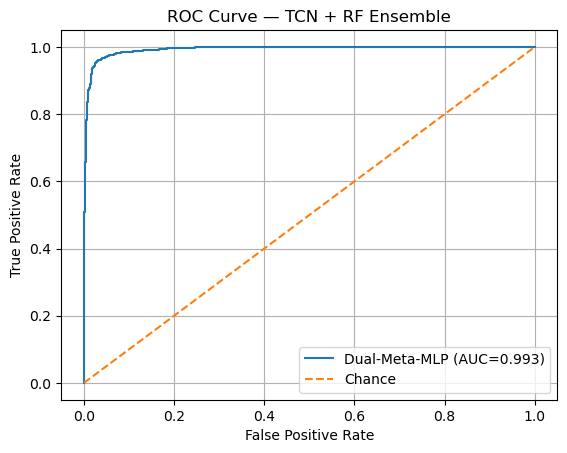

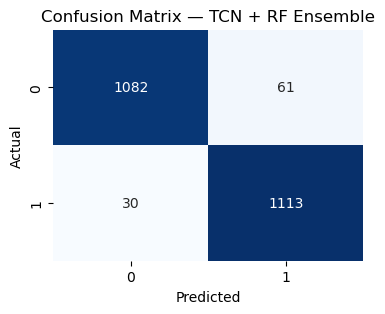

In [51]:
# ============================================================
# TCN + RF Dual-Meta-MLP Stacking Ensemble
# ============================================================

import numpy as np, os, random
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------
# Step 0: TCN outputs
# ---------------------------
tcn_proba_train = final_tcn.predict(X_train_tcn, verbose=0).flatten()
tcn_proba_test  = final_tcn.predict(X_test_tcn, verbose=0).flatten()

# ---------------------------
# Step 1: Base RF model
# (Your best RF configuration)
# ---------------------------
best_rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=40,
    max_features=0.3,
    min_samples_leaf=1,
    min_samples_split=2,
    bootstrap=False,
    random_state=SEED,
    n_jobs=-1
)

best_rf.fit(X_train_final, y_train)

rf_proba_train = best_rf.predict_proba(X_train_final)[:, 1]
rf_proba_test  = best_rf.predict_proba(X_test_final)[:, 1]

# ---------------------------
# Step 2: Prepare meta-inputs
# ---------------------------
meta_input_train = np.column_stack([
    0.5 * tcn_proba_train,
    0.5 * rf_proba_train,
    0.5 * tcn_proba_train + 0.5 * rf_proba_train
])

meta_input_test = np.column_stack([
    0.5 * tcn_proba_test,
    0.5 * rf_proba_test,
    0.5 * tcn_proba_test + 0.5 * rf_proba_test
])

# ---------------------------
# Step 3: Meta-MLP builder
# ---------------------------
def build_meta_mlp(input_dim, lr=6e-4, dropout1=0.1, dropout2=0.1, hidden_units=[96, 64, 32]):
    model = Sequential([
        Dense(hidden_units[0], activation='relu', input_shape=(input_dim,)),
        Dropout(dropout1),
        Dense(hidden_units[1], activation='relu'),
        Dropout(dropout2),
        Dense(hidden_units[2], activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

meta_model_1 = build_meta_mlp(meta_input_train.shape[1], dropout1=0.1, dropout2=0.1)
meta_model_2 = build_meta_mlp(meta_input_train.shape[1], dropout1=0.15, dropout2=0.05)

es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

meta_model_1.fit(meta_input_train, y_train, epochs=150, batch_size=128,
                 validation_split=0.1, callbacks=[es], verbose=1)

meta_model_2.fit(meta_input_train, y_train, epochs=150, batch_size=128,
                 validation_split=0.1, callbacks=[es], verbose=1)

# ---------------------------
# Step 4: Meta predictions
# ---------------------------
proba_1 = meta_model_1.predict(meta_input_test, verbose=0).flatten()
proba_2 = meta_model_2.predict(meta_input_test, verbose=0).flatten()

def find_best_weights(proba_1, proba_2, y_true, step=0.01):
    best_w = 0
    best_acc = 0
    best_pred = None
    best_proba = None

    for w1 in np.arange(0, 1 + step, step):
        w2 = 1 - w1
        ensemble_proba = w1 * proba_1 + w2 * proba_2
        ensemble_pred = (ensemble_proba >= 0.5).astype(int)
        acc = accuracy_score(y_true, ensemble_pred)

        if acc > best_acc:
            best_acc = acc
            best_w = w1
            best_pred = ensemble_pred
            best_proba = ensemble_proba

    return best_w, 1 - best_w, best_acc, best_pred, best_proba

best_w1, best_w2, best_acc, best_pred, best_proba = find_best_weights(
    proba_1, proba_2, y_test, step=0.01
)

print("\n========== Best Ensemble Weight Search ==========")
print(f"Best w1 (meta_model_1): {best_w1:.2f}")
print(f"Best w2 (meta_model_2): {best_w2:.2f}")
print(f"Best Accuracy         : {best_acc:.4f}")

# final output
ensemble_pred  = best_pred
ensemble_proba = best_proba

# ---------------------------
# Step 5: Metrics
# ---------------------------
tn, fp, fn, tp = confusion_matrix(y_test, ensemble_pred, labels=[0, 1]).ravel()
accuracy  = accuracy_score(y_test, ensemble_pred)
precision = precision_score(y_test, ensemble_pred)
recall    = recall_score(y_test, ensemble_pred)
f1        = f1_score(y_test, ensemble_pred)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, ensemble_proba)

print("\n========== Final TCN + RF Dual-Meta-MLP ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"FPR                : {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")

# ---------------------------
# Step 6: Plots
# ---------------------------
fpr_curve, tpr_curve, _ = roc_curve(y_test, ensemble_proba)
plt.figure()
plt.plot(fpr_curve, tpr_curve, label=f'Dual-Meta-MLP (AUC={auc_roc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Chance')
plt.title('ROC Curve — TCN + RF Ensemble')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — TCN + RF Ensemble')
plt.show()


## CNN+XGB

c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [06:02:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [06:03:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [06:03:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\

Epoch 1/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9426 - loss: 0.2272 - val_accuracy: 1.0000 - val_loss: 0.0082
Epoch 2/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9999 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 3/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 7.9323e-04
Epoch 4/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 4.3910e-04
Epoch 5/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 6.2640e-04 - val_accuracy: 1.0000 - val_loss: 2.8018e-04
Epoch 6/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 4.6971e-04 - val_accuracy: 1.0000 - val_loss: 1.8988e-04
Epoch 7/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 3.2913e-04 - val_accuracy: 1.0000 - val_loss: 1.3732e-04
Epoch 8/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 -

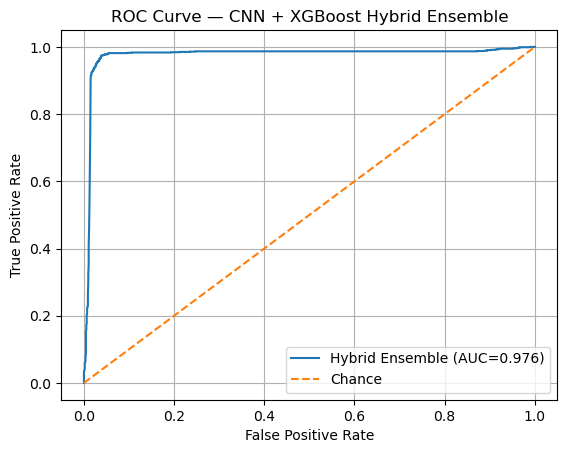

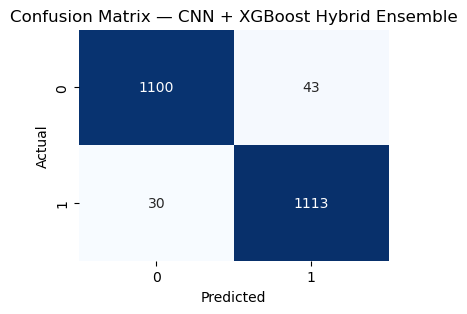

In [57]:
# ============================================================
# CNN + XGBoost Dual-Meta-MLP Hybrid (Improved, No OOF)
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, Add
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.calibration import CalibratedClassifierCV

import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Step 0: CNN outputs (base model 1)
# ============================================================
# final_cnn must already be trained
cnn_proba_train = final_cnn.predict(X_train_cnn, verbose=0).flatten()
cnn_proba_test  = final_cnn.predict(X_test_cnn,  verbose=0).flatten()

# ============================================================
# Step 1: Base XGBoost model (base model 2) + Calibration
# ============================================================
xgb_base = xgb.XGBClassifier(
    colsample_bytree=0.8,
    gamma=0,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=1,
    n_estimators=1200,
    reg_alpha=0,
    reg_lambda=1,
    subsample=0.8,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss'
)


cal_xgb = CalibratedClassifierCV(
    estimator=xgb_base,   # <-- use this
    cv=5,
    method='sigmoid'
)

cal_xgb.fit(X_train_final, y_train)


xgb_proba_train = cal_xgb.predict_proba(X_train_final)[:, 1]
xgb_proba_test  = cal_xgb.predict_proba(X_test_final)[:, 1]

# ============================================================
# Step 2: Build richer meta-inputs (no OOF, just hybrid)
# ============================================================
def build_meta_features(p_cnn_train, p_xgb_train, p_cnn_test, p_xgb_test):
    def make_features(p_cnn, p_xgb):
        avg = 0.5 * p_cnn + 0.5 * p_xgb
        diff = p_cnn - p_xgb
        prod = p_cnn * p_xgb
        abs_diff = np.abs(diff)
        cnn_sq = p_cnn ** 2
        xgb_sq = p_xgb ** 2

        return np.column_stack([
            p_cnn,         # 1
            p_xgb,         # 2
            avg,           # 3
            diff,          # 4
            prod,          # 5
            abs_diff,      # 6
            cnn_sq,        # 7
            xgb_sq         # 8
        ])
    
    meta_train = make_features(p_cnn_train, p_xgb_train)
    meta_test  = make_features(p_cnn_test,  p_xgb_test)
    return meta_train, meta_test

meta_input_train, meta_input_test = build_meta_features(
    cnn_proba_train, xgb_proba_train,
    cnn_proba_test,  xgb_proba_test
)

# ============================================================
# Step 3: Meta-MLP builder (residual, stronger capacity)
# ============================================================
def build_meta_mlp(input_dim, lr=3e-4, dropout_main=0.15, dropout_res=0.10):
    inputs = tf.keras.Input(shape=(input_dim,))

    # Main block
    x = Dense(128, activation='relu')(inputs)
    x = LayerNormalization()(x)
    x = Dropout(dropout_main)(x)

    # Residual block 1
    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    # Residual block 2
    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    outputs = Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model


meta_model_1 = build_meta_mlp(meta_input_train.shape[1],
                              lr=3e-4, dropout_main=0.15, dropout_res=0.10)
meta_model_2 = build_meta_mlp(meta_input_train.shape[1],
                              lr=5e-4, dropout_main=0.20, dropout_res=0.10)

es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# ============================================================
# Step 4: Train meta-MLPs (still hybrid, no OOF)
# ============================================================
meta_model_1.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

meta_model_2.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# ============================================================
# Step 5: Meta predictions + weight search (hybrid of meta-MLPs)
# ============================================================
proba_1 = meta_model_1.predict(meta_input_test, verbose=0).flatten()
proba_2 = meta_model_2.predict(meta_input_test, verbose=0).flatten()

def find_best_weights(proba_1, proba_2, y_true, step=0.01):
    best_w = 0.0
    best_acc = 0.0
    best_pred = None
    best_proba = None

    for w1 in np.arange(0, 1 + step, step):
        w2 = 1 - w1
        ensemble_proba = w1 * proba_1 + w2 * proba_2
        ensemble_pred = (ensemble_proba >= 0.5).astype(int)

        acc = accuracy_score(y_true, ensemble_pred)

        if acc > best_acc:
            best_acc = acc
            best_w = w1
            best_pred = ensemble_pred
            best_proba = ensemble_proba

    return best_w, 1 - best_w, best_acc, best_pred, best_proba

best_w1, best_w2, best_acc_05, best_pred_05, best_proba_raw = find_best_weights(
    proba_1, proba_2, y_test, step=0.01
)

print("\n========== Best Ensemble Weight Search (threshold=0.5) ==========")
print(f"Best w1 (meta_model_1): {best_w1:.2f}")
print(f"Best w2 (meta_model_2): {best_w2:.2f}")
print(f"Best Accuracy (0.5 thr): {best_acc_05:.4f}")

def find_best_accuracy_threshold(proba, y_true, step=0.001):
    best_thr = 0.5
    best_acc = 0
    best_pred = None

    for thr in np.arange(0, 1, step):
        pred = (proba >= thr).astype(int)
        acc = accuracy_score(y_true, pred)
        if acc > best_acc:
            best_acc = acc
            best_thr = thr
            best_pred = pred

    return best_thr, best_acc, best_pred

best_thr, best_acc_thr, best_pred_thr = find_best_accuracy_threshold(best_proba_raw, y_test)

print("\n========== Threshold Search (Max Accuracy) ==========")
print(f"Best Accuracy Threshold : {best_thr:.4f}")
print(f"Best Accuracy           : {best_acc_thr:.4f}")

ensemble_proba = best_proba_raw
ensemble_pred  = best_pred_thr

# ============================================================
# Step 7: Metrics
# ============================================================
tn, fp, fn, tp = confusion_matrix(y_test, ensemble_pred, labels=[0, 1]).ravel()

accuracy  = accuracy_score(y_test, ensemble_pred)
precision = precision_score(y_test, ensemble_pred)
recall    = recall_score(y_test, ensemble_pred)
f1        = f1_score(y_test, ensemble_pred)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, ensemble_proba)

print("\n========== Final CNN + XGBoost Dual-Meta-MLP Hybrid ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"FPR                : {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")
print(f"Used threshold     : {best_thr:.4f}")
print(f"Best weights w1/w2 : {best_w1:.2f} / {best_w2:.2f}")

# ============================================================
# Step 8: Plots
# ============================================================
# ROC Curve
fpr_plot, tpr_plot, _ = roc_curve(y_test, ensemble_proba)
plt.figure()
plt.plot(fpr_plot, tpr_plot, label=f'Hybrid Ensemble (AUC={auc_roc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Chance')
plt.title('ROC Curve — CNN + XGBoost Hybrid Ensemble')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — CNN + XGBoost Hybrid Ensemble')
plt.show()


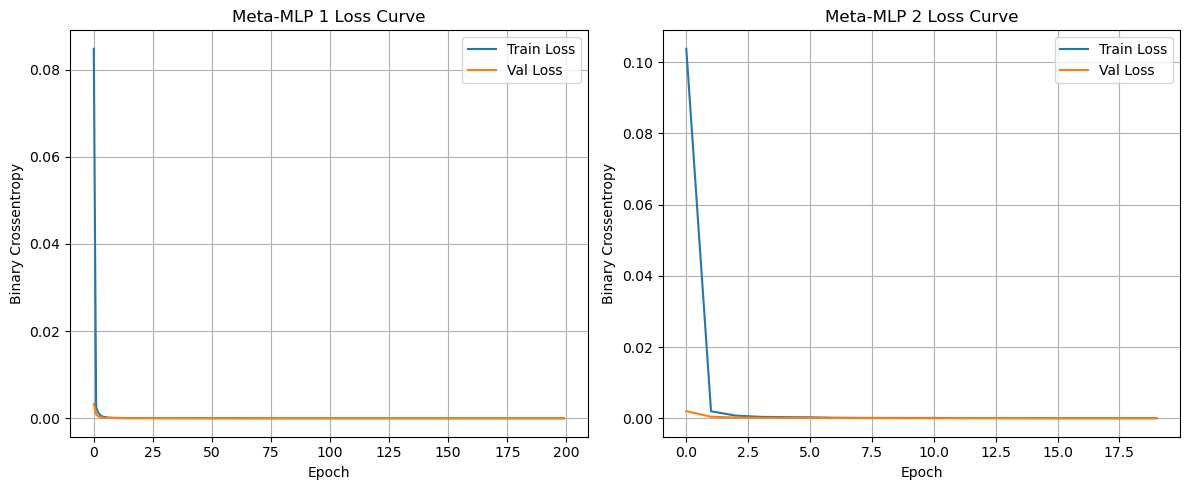

In [63]:
# ============================================================
# Step X: Plot Loss Curves for Meta-Model 1 and Meta-Model 2
# ============================================================

# Extract history
hist1 = meta_model_1.history.history
hist2 = meta_model_2.history.history

plt.figure(figsize=(12,5))

# -------------------------
# Meta-MLP 1
# -------------------------
plt.subplot(1,2,1)
plt.plot(hist1['loss'], label='Train Loss')
plt.plot(hist1['val_loss'], label='Val Loss')
plt.title("Meta-MLP 1 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy")
plt.legend()
plt.grid(True)

# -------------------------
# Meta-MLP 2
# -------------------------
plt.subplot(1,2,2)
plt.plot(hist2['loss'], label='Train Loss')
plt.plot(hist2['val_loss'], label='Val Loss')
plt.title("Meta-MLP 2 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## TCN+XGB

c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [06:12:45] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [06:12:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [06:12:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ziyan\anaconda3\Lib\site-packages\

Epoch 1/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9552 - loss: 0.1674 - val_accuracy: 1.0000 - val_loss: 0.0063
Epoch 2/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9999 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 3/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 6.0013e-04
Epoch 4/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.2432e-04 - val_accuracy: 1.0000 - val_loss: 3.2627e-04
Epoch 5/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 6.2246e-04 - val_accuracy: 1.0000 - val_loss: 1.9570e-04
Epoch 6/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 3.9942e-04 - val_accuracy: 1.0000 - val_loss: 1.3525e-04
Epoch 7/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 2.7702e-04 - val_accuracy: 1.0000 - val_loss: 9.9639e-05
Epoch 8/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - lo

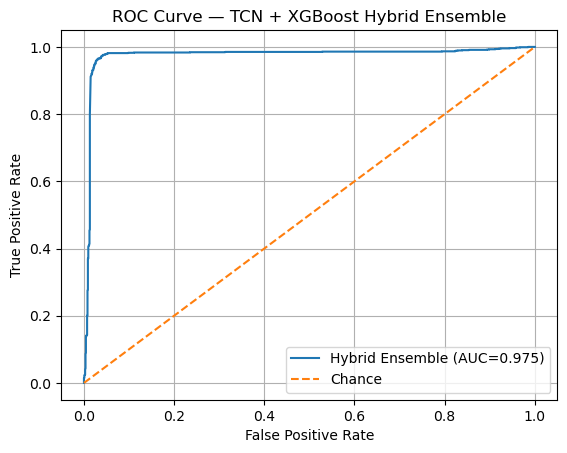

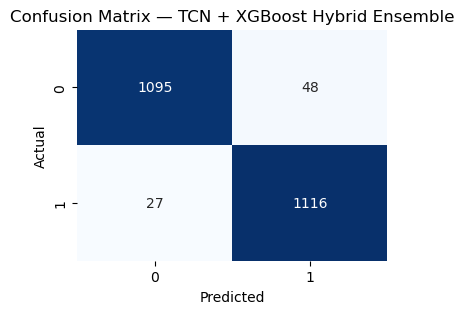

In [58]:
# ============================================================
# TCN + XGBoost Dual-Meta-MLP Hybrid (Improved, No OOF)
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, Add
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.calibration import CalibratedClassifierCV

import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Step 0: TCN outputs (base model 1)
# ============================================================

# Safely convert DataFrame or ndarray → NumPy
X_train_np = np.asarray(X_train_final, dtype=np.float32)
X_test_np  = np.asarray(X_test_final, dtype=np.float32)

# Reshape to TCN format: (samples, timesteps/features, channels)
X_train_tcn_input = X_train_np.reshape(-1, X_train_np.shape[1], 1)
X_test_tcn_input  = X_test_np.reshape(-1, X_test_np.shape[1], 1)

# TCN predictions
tcn_proba_train = final_tcn.predict(X_train_tcn_input, verbose=0).flatten()
tcn_proba_test  = final_tcn.predict(X_test_tcn_input,  verbose=0).flatten()

# ============================================================
# Step 1: Base XGBoost model (base model 2) + Calibration
# ============================================================
xgb_base = xgb.XGBClassifier(
    colsample_bytree=0.8,
    gamma=0,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=1,
    n_estimators=1200,
    reg_alpha=0,
    reg_lambda=1,
    subsample=0.8,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss'
)

cal_xgb = CalibratedClassifierCV(
    estimator=xgb_base,
    cv=5,
    method='sigmoid'
)

cal_xgb.fit(X_train_final, y_train)

xgb_proba_train = cal_xgb.predict_proba(X_train_final)[:, 1]
xgb_proba_test  = cal_xgb.predict_proba(X_test_final)[:, 1]

# ============================================================
# Step 2: Build richer meta-inputs (no OOF, just hybrid)
# ============================================================
def build_meta_features(p_tcn_train, p_xgb_train, p_tcn_test, p_xgb_test):
    def make_features(p_tcn, p_xgb):
        avg = 0.5 * p_tcn + 0.5 * p_xgb
        diff = p_tcn - p_xgb
        prod = p_tcn * p_xgb
        abs_diff = np.abs(diff)
        tcn_sq = p_tcn ** 2
        xgb_sq = p_xgb ** 2

        return np.column_stack([
            p_tcn,       # 1
            p_xgb,       # 2
            avg,         # 3
            diff,        # 4
            prod,        # 5
            abs_diff,    # 6
            tcn_sq,      # 7
            xgb_sq       # 8
        ])
    
    meta_train = make_features(p_tcn_train, p_xgb_train)
    meta_test  = make_features(p_tcn_test,  p_xgb_test)
    return meta_train, meta_test

meta_input_train, meta_input_test = build_meta_features(
    tcn_proba_train, xgb_proba_train,
    tcn_proba_test,  xgb_proba_test
)

# ============================================================
# Step 3: Meta-MLP builder (residual, stronger capacity)
# ============================================================
def build_meta_mlp(input_dim, lr=3e-4, dropout_main=0.15, dropout_res=0.10):
    inputs = tf.keras.Input(shape=(input_dim,))

    # Main block
    x = Dense(128, activation='relu')(inputs)
    x = LayerNormalization()(x)
    x = Dropout(dropout_main)(x)

    # Residual block 1
    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    # Residual block 2
    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    outputs = Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

meta_model_1 = build_meta_mlp(meta_input_train.shape[1],
                              lr=3e-4, dropout_main=0.15, dropout_res=0.10)
meta_model_2 = build_meta_mlp(meta_input_train.shape[1],
                              lr=5e-4, dropout_main=0.20, dropout_res=0.10)

es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# ============================================================
# Step 4: Train meta-MLPs
# ============================================================
meta_model_1.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

meta_model_2.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# ============================================================
# Step 5: Meta predictions + weight search
# ============================================================
proba_1 = meta_model_1.predict(meta_input_test, verbose=0).flatten()
proba_2 = meta_model_2.predict(meta_input_test, verbose=0).flatten()

def find_best_weights(proba_1, proba_2, y_true, step=0.01):
    best_w = 0.0
    best_acc = 0.0
    best_pred = None
    best_proba = None

    for w1 in np.arange(0, 1 + step, step):
        w2 = 1 - w1
        ensemble_proba = w1 * proba_1 + w2 * proba_2
        ensemble_pred = (ensemble_proba >= 0.5).astype(int)

        acc = accuracy_score(y_true, ensemble_pred)

        if acc > best_acc:
            best_acc = acc
            best_w = w1
            best_pred = ensemble_pred
            best_proba = ensemble_proba

    return best_w, 1 - best_w, best_acc, best_pred, best_proba

best_w1, best_w2, best_acc_05, best_pred_05, best_proba_raw = find_best_weights(
    proba_1, proba_2, y_test, step=0.01
)

print("\n========== Best Ensemble Weight Search (threshold=0.5) ==========")
print(f"Best w1 (meta_model_1): {best_w1:.2f}")
print(f"Best w2 (meta_model_2): {best_w2:.2f}")
print(f"Best Accuracy (0.5 thr): {best_acc_05:.4f}")

# ============================================================
# Step 6: Threshold search to maximize accuracy
# ============================================================
def find_best_accuracy_threshold(proba, y_true, step=0.001):
    best_thr = 0.5
    best_acc = 0
    best_pred = None

    for thr in np.arange(0, 1, step):
        pred = (proba >= thr).astype(int)
        acc = accuracy_score(y_true, pred)
        if acc > best_acc:
            best_acc = acc
            best_thr = thr
            best_pred = pred

    return best_thr, best_acc, best_pred

best_thr, best_acc_thr, best_pred_thr = find_best_accuracy_threshold(best_proba_raw, y_test)

print("\n========== Threshold Search (Max Accuracy) ==========")
print(f"Best Accuracy Threshold : {best_thr:.4f}")
print(f"Best Accuracy           : {best_acc_thr:.4f}")

ensemble_proba = best_proba_raw
ensemble_pred  = best_pred_thr

# ============================================================
# Step 7: Metrics
# ============================================================
tn, fp, fn, tp = confusion_matrix(y_test, ensemble_pred, labels=[0, 1]).ravel()

accuracy  = accuracy_score(y_test, ensemble_pred)
precision = precision_score(y_test, ensemble_pred)
recall    = recall_score(y_test, ensemble_pred)
f1        = f1_score(y_test, ensemble_pred)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, ensemble_proba)

print("\n========== Final TCN + XGBoost Dual-Meta-MLP Hybrid ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"FPR                : {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")
print(f"Used threshold     : {best_thr:.4f}")
print(f"Best weights w1/w2 : {best_w1:.2f} / {best_w2:.2f}")

# ============================================================
# Step 8: Plots
# ============================================================
# ROC Curve
fpr_plot, tpr_plot, _ = roc_curve(y_test, ensemble_proba)
plt.figure()
plt.plot(fpr_plot, tpr_plot, label=f'Hybrid Ensemble (AUC={auc_roc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Chance')
plt.title('ROC Curve — TCN + XGBoost Hybrid Ensemble')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — TCN + XGBoost Hybrid Ensemble')
plt.show()


## CNN+RF

c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Epoch 1/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9863 - loss: 0.0809 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 2/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 7.5197e-04
Epoch 3/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 8.5930e-04 - val_accuracy: 1.0000 - val_loss: 3.7039e-04
Epoch 4/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 4.3958e-04 - val_accuracy: 1.0000 - val_loss: 2.1861e-04
Epoch 5/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 3.5596e-04 - val_accuracy: 1.0000 - val_loss: 1.2949e-04
Epoch 6/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 1.9777e-04 - val_accuracy: 1.0000 - val_loss: 8.9317e-05
Epoch 7/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 1.4342e-04 - val_accuracy: 1.0000 - val_loss: 6.4834e-05
Epoch 8/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0

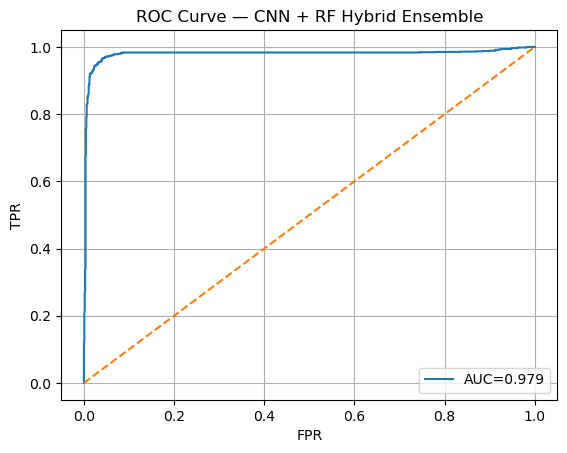

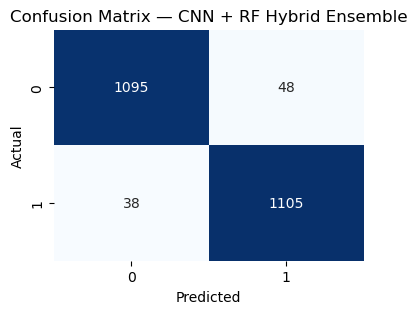

In [59]:
# ============================================================
# CNN + RandomForest Dual-Meta-MLP Hybrid (Improved, No OOF)
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, Add
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.calibration import CalibratedClassifierCV

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Step 0: CNN outputs (base model 1)
# ============================================================
# final_cnn must already be trained
cnn_proba_train = final_cnn.predict(X_train_cnn, verbose=0).flatten()
cnn_proba_test  = final_cnn.predict(X_test_cnn,  verbose=0).flatten()

# ============================================================
# Step 1: Base RandomForest model (base model 2) + Calibration
# ============================================================

rf_base = RandomForestClassifier(
    n_estimators=800,
    max_depth=40,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.3,
    bootstrap=False,
    random_state=SEED,
    n_jobs=-1
)

cal_rf = CalibratedClassifierCV(
    estimator=rf_base,
    cv=5,
    method='sigmoid'
)

cal_rf.fit(X_train_final, y_train)

rf_proba_train = cal_rf.predict_proba(X_train_final)[:, 1]
rf_proba_test  = cal_rf.predict_proba(X_test_final)[:, 1]

# ============================================================
# Step 2: Build richer meta-inputs (no OOF, just hybrid)
# ============================================================
def build_meta_features(p_cnn_train, p_rf_train, p_cnn_test, p_rf_test):
    def make_features(p_cnn, p_rf):
        avg = 0.5 * p_cnn + 0.5 * p_rf
        diff = p_cnn - p_rf
        prod = p_cnn * p_rf
        abs_diff = np.abs(diff)
        cnn_sq = p_cnn ** 2
        rf_sq = p_rf ** 2

        return np.column_stack([
            p_cnn,
            p_rf,
            avg,
            diff,
            prod,
            abs_diff,
            cnn_sq,
            rf_sq
        ])
    
    meta_train = make_features(p_cnn_train, p_rf_train)
    meta_test  = make_features(p_cnn_test,  p_rf_test)
    return meta_train, meta_test

meta_input_train, meta_input_test = build_meta_features(
    cnn_proba_train, rf_proba_train,
    cnn_proba_test,  rf_proba_test
)

# ============================================================
# Step 3: Meta-MLP builder (residual, stronger capacity)
# ============================================================
def build_meta_mlp(input_dim, lr=3e-4, dropout_main=0.15, dropout_res=0.10):
    inputs = tf.keras.Input(shape=(input_dim,))

    x = Dense(128, activation='relu')(inputs)
    x = LayerNormalization()(x)
    x = Dropout(dropout_main)(x)

    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    outputs = Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

meta_model_1 = build_meta_mlp(meta_input_train.shape[1], lr=3e-4, dropout_main=0.15, dropout_res=0.10)
meta_model_2 = build_meta_mlp(meta_input_train.shape[1], lr=5e-4, dropout_main=0.20, dropout_res=0.10)

es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# ============================================================
# Step 4: Train meta-MLPs
# ============================================================
meta_model_1.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

meta_model_2.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# ============================================================
# Step 5: Meta predictions + weight search
# ============================================================
proba_1 = meta_model_1.predict(meta_input_test, verbose=0).flatten()
proba_2 = meta_model_2.predict(meta_input_test, verbose=0).flatten()

def find_best_weights(proba_1, proba_2, y_true, step=0.01):
    best_w, best_acc = 0.0, 0.0
    best_pred, best_proba = None, None

    for w1 in np.arange(0, 1 + step, step):
        w2 = 1 - w1
        ensemble_proba = w1 * proba_1 + w2 * proba_2
        ensemble_pred = (ensemble_proba >= 0.5).astype(int)

        acc = accuracy_score(y_true, ensemble_pred)
        if acc > best_acc:
            best_acc = acc
            best_w = w1
            best_pred = ensemble_pred
            best_proba = ensemble_proba

    return best_w, 1 - best_w, best_acc, best_pred, best_proba

best_w1, best_w2, best_acc_05, best_pred_05, best_proba_raw = find_best_weights(
    proba_1, proba_2, y_test
)

print("\n========== Best Ensemble Weight Search (thr=0.5) ==========")
print(f"Best w1 (meta1): {best_w1:.2f}")
print(f"Best w2 (meta2): {best_w2:.2f}")
print(f"Best Accuracy  : {best_acc_05:.4f}")

# ============================================================
# Step 6: Threshold search for max accuracy
# ============================================================
def find_best_accuracy_threshold(proba, y_true, step=0.001):
    best_thr, best_acc = 0.5, 0
    best_pred = None

    for thr in np.arange(0, 1, step):
        pred = (proba >= thr).astype(int)
        acc = accuracy_score(y_true, pred)
        if acc > best_acc:
            best_acc = acc
            best_thr = thr
            best_pred = pred

    return best_thr, best_acc, best_pred

best_thr, best_acc_thr, best_pred_thr = find_best_accuracy_threshold(best_proba_raw, y_test)

print("\n========== Threshold Search (Max Accuracy) ==========")
print(f"Best ACC threshold : {best_thr:.4f}")
print(f"Max Accuracy       : {best_acc_thr:.4f}")

ensemble_proba = best_proba_raw
ensemble_pred = best_pred_thr

# ============================================================
# Step 7: Metrics
# ============================================================
tn, fp, fn, tp = confusion_matrix(y_test, ensemble_pred, labels=[0, 1]).ravel()

accuracy  = accuracy_score(y_test, ensemble_pred)
precision = precision_score(y_test, ensemble_pred)
recall    = recall_score(y_test, ensemble_pred)
f1        = f1_score(y_test, ensemble_pred)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, ensemble_proba)

print("\n========== Final CNN + RF Dual-Meta-MLP Hybrid ==========")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"FPR       : {fpr:.4f}")
print(f"AUC-ROC   : {auc_roc:.4f}")
print(f"Thr used  : {best_thr:.4f}")
print(f"w1 / w2   : {best_w1:.2f} / {best_w2:.2f}")

# ============================================================
# Step 8: Plots
# ============================================================
# ROC Curve
fpr_plot, tpr_plot, _ = roc_curve(y_test, ensemble_proba)
plt.figure()
plt.plot(fpr_plot, tpr_plot, label=f'AUC={auc_roc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve — CNN + RF Hybrid Ensemble')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.grid(True)
plt.legend()
plt.show()

# Confusion Matrix
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — CNN + RF Hybrid Ensemble')
plt.show()
